# Workflow Patterns

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain.chat_models import init_chat_model

llm = init_chat_model("openai:gpt-4.1-mini")

## 1. Routing Pattern
입력 유형에 따라 다른 노드로 보내는 패턴을 의미한다.

다음 상황에 적합하게 사용 될 수 있다.
1. 요청 유형별로 프롬프트가 달라져야 할 때
2. 처리 방식이 명확히 나뉠 때
3. 모든 요청을 하나의 프롬프트로 처리하면 품질이 떨어질 때

In [4]:
from pydantic import BaseModel, Field
from typing import Annotated, Literal
from typing_extensions import TypedDict

class RouteDecision(BaseModel):
    route : Literal['translation','summary','qa'] = Field(
        description='사용자 요청을 처리할 경로'
    )
    reason:str = Field(
        description='해당 경로를 선택한 이유'
    )

route_llm = llm.with_structured_output(RouteDecision)

class RoutingState(TypedDict):
    user_input:str
    route:str
    reason:str
    answer:str

In [5]:
def classify_request(state:RoutingState):
    """사용자 요청을 번역, 요약, 일반 질문 중 하나로 분류한다."""

    desicion = route_llm.invoke(
        [
            {
                'role':"system",
                'content':(
                    "사용자 요청을 다음 세 가지 중 하나로 분류하세요. \n"
                    "-translation: 번역요청\n"
                    "-summary: 요약 요청\n"
                    "-qa: 일반 질문 또는 설명 요청\n"
                )
            },
            {
                "role":"user",
                "content":state["user_input"]
            }
        ]
    )

    return {
        "route" : desicion.route,
        "reason": desicion.reason
    }

def route_by_decision(state: RoutingState):
    """분류 결과에 따라 다음 노드를 결정한다."""
    return state['route']

In [6]:
def translation_node(state:RoutingState):
    """번역 요청을 처리한다."""

    response = llm.invoke(
        [
            {
                "role":"system",
                "content":"사용자의 문장을 자연스러운 한국어로 번역하세요."
            },
            {
                "role":"user",
                "content":state['user_input']
            }
        ]
    )

    return {"answer":response.content}

def summary_node(state:RoutingState):
    """요약 요청을 처리한다."""

    response = llm.invoke(
        [
            {
                "role":"system",
                "content":"사용자가 제공한 내용을 핵심만 3문장 이내로 요약하세요."
            },
            {
                "role":"user",
                "content":state['user_input']
            }
        ]
    )

    return {"answer":response.content}

def qa_node(state:RoutingState):
    """일반 질문을 처리한다."""

    response = llm.invoke(
        [
            {
                "role":"system",
                "content":"사용자의 질문에 친절하고 정확하게 답변하세요."
            },
            {
                "role":"user",
                "content":state['user_input']
            }
        ]
    )

    return {"answer":response.content}

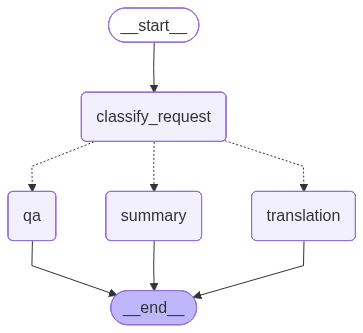

In [7]:
from langgraph.graph import StateGraph,START,END

routing_builder = StateGraph(RoutingState)

routing_builder.add_node("classify_request",classify_request)
routing_builder.add_node("translation",translation_node)
routing_builder.add_node("summary",summary_node)
routing_builder.add_node("qa",qa_node)

routing_builder.add_edge(START,'classify_request')
routing_builder.add_conditional_edges(
    'classify_request',
    route_by_decision,
    {'translation':'translation',
     'summary':'summary',
     'qa':'qa'}
)

routing_builder.add_edge('translation',END)
routing_builder.add_edge('summary',END)
routing_builder.add_edge('qa',END)

routing_graph = routing_builder.compile()
routing_graph

In [9]:
# 번역 질문
routing_result = routing_graph.invoke({
    "user_input":"다음 문장을 한국어로 번역해줘: I usually avoid spicy food."
})

print('선택된 경로: ',routing_result['route'])
print('선택된 이유: ',routing_result['reason'])
print()
print(routing_result['answer'])


선택된 경로:  translation
선택된 이유:  사용자가 영어 문장을 한국어로 번역해 달라고 요청했기 때문에 번역 요청으로 분류했습니다.

저는 보통 매운 음식을 피해요.


In [ ]:
# 일반 질문
routing_result = routing_graph.invoke({
    "user_input":"지구의 대기권은 어떤 층으로 구성 되어 있어?"
})

print('선택된 경로: ',routing_result['route'])
print('선택된 이유: ',routing_result['reason'])
print()
print(routing_result['answer'])


선택된 경로:  qa
선택된 이유:  사용자가 지구의 대기권 구성에 대해 일반적인 질문을 했기 때문에 QA로 분류함.

지구의 대기권은 여러 층으로 구성되어 있으며, 주로 아래와 같이 구분됩니다:

1. 대류권 (Troposphere)  
- 지표면에서 약 8~15km까지 위치  
- 우리가 사는 곳이며, 날씨 현상이 일어나는 층  
- 온도는 고도가 높아질수록 감소

2. 성층권 (Stratosphere)  
- 대류권 윗부분에서 약 50km 높이까지  
- 오존층이 존재하여 자외선을 흡수  
- 온도는 고도가 높아질수록 증가

3. 중간권 (Mesosphere)  
- 성층권 윗부분에서 약 85km 높이까지  
- 온도는 다시 감소하며, 가장 차가운 층  
- 유성들이 타는 곳

4. 열권 (Thermosphere)  
- 중간권 윗부분에서 약 600km까지  
- 태양 자외선과 X선 흡수로 매우 높은 온도  
- 오로라 현상이 일어나는 층

5. 외기권 (Exosphere)  
- 열권 윗부분에서 수천 km까지 퍼져 있음  
- 대기가 매우 희박하여 우주와 연결되는 경계층

이렇게 다섯 층으로 이루어져 있으며, 각 층마다 온도 변화와 특성이 다릅니다.


In [11]:
# 요약 질문
routing_result = routing_graph.invoke({
    "user_input":"""아래 분장을 요약해줘.
    지구의 대기권은 여러 층으로 구성되어 있으며, 주로 아래와 같이 구분됩니다:

1. 대류권 (Troposphere)  
- 지표면에서 약 8~15km까지 위치  
- 우리가 사는 곳이며, 날씨 현상이 일어나는 층  
- 온도는 고도가 높아질수록 감소

2. 성층권 (Stratosphere)  
- 대류권 윗부분에서 약 50km 높이까지  
- 오존층이 존재하여 자외선을 흡수  
- 온도는 고도가 높아질수록 증가

3. 중간권 (Mesosphere)  
- 성층권 윗부분에서 약 85km 높이까지  
- 온도는 다시 감소하며, 가장 차가운 층  
- 유성들이 타는 곳

4. 열권 (Thermosphere)  
- 중간권 윗부분에서 약 600km까지  
- 태양 자외선과 X선 흡수로 매우 높은 온도  
- 오로라 현상이 일어나는 층

5. 외기권 (Exosphere)  
- 열권 윗부분에서 수천 km까지 퍼져 있음  
- 대기가 매우 희박하여 우주와 연결되는 경계층

이렇게 다섯 층으로 이루어져 있으며, 각 층마다 온도 변화와 특성이 다릅니다.
    """
})

print('선택된 경로: ',routing_result['route'])
print('선택된 이유: ',routing_result['reason'])
print()
print(routing_result['answer'])


선택된 경로:  summary
선택된 이유:  사용자는 지구 대기권의 여러 층에 대한 긴 설명을 주고 이를 요약해달라고 요청했으므로 요약 요청에 해당합니다.

지구의 대기권은 대류권, 성층권, 중간권, 열권, 외기권의 다섯 층으로 구성되며, 각 층은 고도에 따라 온도 변화와 특징이 다릅니다. 대류권은 우리가 사는 곳이자 날씨가 발생하는 층이며, 성층권에는 오존층이 있어 자외선을 흡수합니다. 중간권은 가장 차가운 층이고, 열권은 태양 복사에 의해 온도가 매우 높으며 오로라가 발생하며, 외기권은 대기가 매우 희박해 우주와 연결되는 경계층입니다.


## 2. Parallelization Pattern
여러 노드를 동시에 실행하고 결과를 합치는 패턴이다.

이 패턴은 다음 상황에 적합하다.
1. 서로 독립적인 분석을 동시에 수행할 수 있을 때
2. 여러 관점의 결과를 합쳐야 할 때
3. 순차 실행보다 병렬 실행이 구조적으로 자연스러울 때

In [12]:
class ParallelState(TypedDict):
    topic:str
    market_analysis:str
    user_analysis:str
    risk_analysis:str
    final_report:str

In [13]:
def market_analysis_node(state:ParallelState):
    """시장 관점에서 주제를 분석한다.."""

    response = llm.invoke(
        [
            {
                "role":"system",
                "content":"주어진 주제를 시장성과 수요 관점에서 간단히 분석하세요."
            },
            {
                "role":"user",
                "content":state['topic']
            }
        ]
    )

    return {"market_analysis":response.content}

def user_analysis_node(state:ParallelState):
    """사용자 관점에서 주제를 분석한다.."""

    response = llm.invoke(
        [
            {
                "role":"system",
                "content":"주어진 주제를 사용자 경험과 사용 가치 관점에서 간단히 분석하세요."
            },
            {
                "role":"user",
                "content":state['topic']
            }
        ]
    )

    return {"user_analysis":response.content}

def risk_analysis_node(state:ParallelState):
    """위험 요소 관점에서 주제를 분석한다.."""

    response = llm.invoke(
        [
            {
                "role":"system",
                "content":"주어진 주제를 위험 요소과 주의할 점에서 간단히 분석하세요."
            },
            {
                "role":"user",
                "content":state['topic']
            }
        ]
    )

    return {"risk_analysis":response.content}

In [22]:
def synthesize_parallel_node(state: ParallelState):
    """여러 관점의 분석 결과를 종합한다."""

    response = llm.invoke(
        [
            {
                "role":"system",
                "content":"여러 관점의 분석 결과를 종합해 짧은 의사결정 메모를 작성하세요."
            },
            {
                "role":"user",
                "content":(
                    f"주제: {state['topic']}\n\n"
                    f"[시장 관점]: {state['market_analysis']}\n\n"
                    f"[사용자 관점]: {state['user_analysis']}\n\n"
                    f"[위험 요소 관점]: {state['risk_analysis']}\n\n"
                )
            }
        ]
    )

    return {"final_report":response.content}

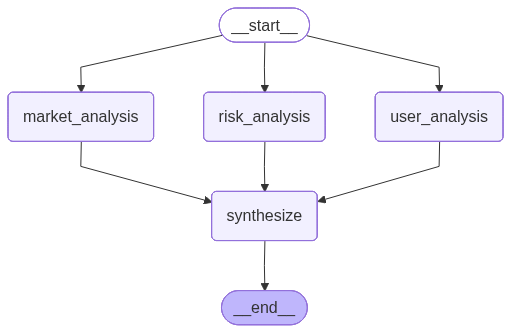

In [23]:
parallel_builder = StateGraph(ParallelState)

parallel_builder.add_node("market_analysis",market_analysis_node)
parallel_builder.add_node("user_analysis",user_analysis_node)
parallel_builder.add_node("risk_analysis",risk_analysis_node)
parallel_builder.add_node("synthesize",synthesize_parallel_node)

# START에서 여러 노드로 동시에 연결하면 병렬 실행 구조가 된다. 
parallel_builder.add_edge(START,'market_analysis')
parallel_builder.add_edge(START,'user_analysis')
parallel_builder.add_edge(START,'risk_analysis')

# 세 분석 노드가 끝난 뒤 synthesize 노드에서 결과를 합친다.
parallel_builder.add_edge("market_analysis","synthesize")
parallel_builder.add_edge("user_analysis","synthesize")
parallel_builder.add_edge("risk_analysis","synthesize")

parallel_builder.add_edge("synthesize",END)

parallel_graph = parallel_builder.compile()
parallel_graph

In [25]:
parallel_result = parallel_graph.invoke({
    'topic': '개인 맞춤형 여행 추천 서비스'
})

print("[시장 관점]")
print(parallel_result['market_analysis'])
print('-'*100)
print("[사용자 관점]")
print(parallel_result['user_analysis'])
print('-'*100)
print("[위험 관점]")
print(parallel_result['risk_analysis'])
print('-'*100)
print("[최종 레포트]")
print(parallel_result['final_report'])
print('-'*100)

[시장 관점]
개인 맞춤형 여행 추천 서비스는 현재 여행 시장에서 큰 성장 잠재력을 가진 분야입니다. 다음과 같은 시장성과 수요 측면에서 긍정적인 요소들을 들 수 있습니다.

1. 시장성
- 여행 산업의 지속적 성장: 전 세계적으로 여행 산업은 꾸준히 성장하고 있으며, 특히 디지털 기술의 발전으로 온라인 기반 서비스가 확대되고 있습니다.
- 맞춤형 서비스 선호 증가: 소비자들은 점점 더 자기 취향과 요구에 맞춘 맞춤형 경험을 원하고 있어 개인화 서비스에 대한 수요가 높습니다.
- 데이터 및 AI 기술 활용 가능성: 사용자 데이터 분석과 인공지능 기술을 활용해 더욱 정교한 추천이 가능, 경쟁력 있는 서비스 제공이 용이합니다.

2. 수요
- 다양해지는 여행자 요구: 연령, 취향, 예산에 따라 매우 다양한 여행 스타일이 존재하며, 이를 충족시키려는 수요가 증가하고 있습니다.
- 편리성 추구: 여행 계획에 소요되는 시간과 노력을 줄이고, 최적의 여행을 제안받고자 하는 소비자들의 니즈가 강합니다.
- 모바일 및 온라인 채널 사용 확산: 스마트폰 보급률 증가와 함께 모바일 기반 맞춤형 추천 서비스 이용률도 높아지고 있습니다.

종합적으로, 개인 맞춤형 여행 추천 서비스는 디지털화된 여행 시장 내에서 소비자의 편의와 만족도를 크게 향상시킬 수 있는 사업 분야로서 높은 시장성과 수요를 갖추고 있습니다. 다만, 맞춤화의 정확성, 개인정보 보호, 경쟁 서비스 대비 차별화 요소 확보가 성공의 관건입니다.
----------------------------------------------------------------------------------------------------
[사용자 관점]
개인 맞춤형 여행 추천 서비스는 사용자의 취향, 관심사, 예산, 여행 이력 등을 바탕으로 최적의 여행지와 일정을 제안하는 서비스입니다.

1. 사용자 경험 측면  
- **개인화**: 사용자는 자신만을 위한 맞춤형 추천을 받아 만족도가 높아진다.  
- **간편성**: 복잡한 정보 검

## 3. Evaluator-Optimizer Pattern
생성 결과를 평가하고 부족하면 다시 개선하는 패턴이다.
답변 품질을 일정 수준 이상으로 끌어올리고 싶을 때 유용하다.

In [26]:
class Evaluation(BaseModel):
    grade: Literal["pass","fail"] = Field(
        description="초안이 요구사항을 만족하면 pass, 부족하면 fail"
    )
    feedback: str = Field(
        description="개선이 필요한 경우 구체적인 피드백"
    )

evaluator_llm = llm.with_structured_output(Evaluation)

class EvalState(TypedDict):
    task:str
    draft:str
    feedback:str
    grade:str
    iteration:int

In [27]:
def generate_draft_node(state: EvalState):
    """초안을 생성하거나, 피드백을 반영해 다시 작성한다."""

    feedback = state.get("feedback", "")
    iteration = state.get("iteration", 0)

    if feedback:
        # 이전 평가에서 fail을 받은 경우에는 피드백과 이전 초안을 함께 전달한다.
        # 이렇게 해야 단순 재생성이 아니라 개선 작업이 된다.
        prompt = (
            f"다음 작업에 대한 초안을 피드백을 반영해 개선하세요.\n\n"
            f"작업: {state['task']}\n\n"
            f"이전 초안:\n{state.get('draft', '')}\n\n"
            f"피드백:\n{feedback}"
        )
    else:
        # 처음 실행될 때는 피드백이 없으므로 초안을 새로 작성한다.
        prompt = f"다음 작업에 대한 초안을 작성하세요.\n\n작업: {state['task']}"

    response = llm.invoke(
        [
            {
                "role": "system",
                "content": (
                    "당신은 사용자의 작업 요구사항에 맞는 초안을 작성하는 작성자입니다. "
                    "요구사항을 충실히 반영하되, 처음에는 핵심 내용을 중심으로 간결하게 작성하세요. "
                    "이전 피드백이 제공되면 피드백을 반영해 더 완성도 높은 초안으로 개선하세요."
                ),
            },
            {
                "role": "user",
                "content": prompt,
            },
        ]
    )

    return {
        "draft": response.content,
        "iteration": iteration + 1,
    }


def evaluate_draft_node(state: EvalState):
    """초안이 작업 요구사항을 만족하는지 평가한다."""

    # 수업에서는 Evaluator-Optimizer의 반복 구조를 반드시 확인하기 위해
    # 첫 번째 초안은 의도적으로 fail 처리한다.
    # 실제 서비스 코드에서는 이런 강제 fail 로직을 넣지 않는다.
    if state["iteration"] == 1:
        return {
            "grade": "fail",
            "feedback": (
                "첫 번째 초안은 반복 구조 확인을 위해 개선 대상으로 처리합니다. "
                "작업 요구사항을 더 명확히 반영하고, 내용의 구체성, 전달력, 완성도를 보강하세요."
            ),
        }

    # 두 번째 평가부터는 LLM이 실제로 pass/fail을 판단한다.
    evaluation = evaluator_llm.invoke(
        [
            {
                "role": "system",
                "content": (
                    "당신은 초안을 검토하는 평가자입니다.\n"
                    "주어진 작업 요구사항과 초안을 비교하여 초안이 요구사항을 충분히 만족하는지 평가하세요.\n\n"
                    "다음 기준을 바탕으로 평가합니다.\n"
                    "1. 작업에서 요구한 목적과 대상이 초안에 반영되어 있는가?\n"
                    "2. 핵심 내용이 빠지지 않고 포함되어 있는가?\n"
                    "3. 표현이 지나치게 추상적이지 않고 구체적인가?\n"
                    "4. 문장의 흐름이 자연스럽고 실제로 사용할 수 있는 수준인가?\n\n"
                    "모든 기준을 충분히 만족하면 pass를 주세요.\n"
                    "하나라도 부족하면 fail을 주고, 무엇을 어떻게 보완해야 하는지 구체적으로 피드백하세요."
                ),
            },
            {
                "role": "user",
                "content": (
                    f"작업 요구사항:\n{state['task']}\n\n"
                    f"초안:\n{state['draft']}"
                ),
            },
        ]
    )

    return {
        "grade": evaluation.grade,
        "feedback": evaluation.feedback,
    }


def should_continue(state: EvalState):
    """평가 결과에 따라 종료할지 다시 생성할지 결정한다."""

    if state["grade"] == "pass":
        return "end"

    # 수업용 예제에서는 무한 반복을 막기 위해 최대 3회까지만 생성한다.
    if state["iteration"] >= 3:
        return "end"

    return "revise"

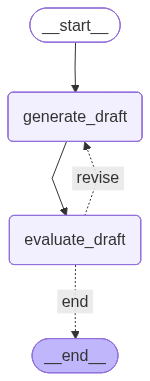

In [28]:
eval_builder = StateGraph(EvalState)

eval_builder.add_node("generate_draft",generate_draft_node)
eval_builder.add_node("evaluate_draft",evaluate_draft_node)

eval_builder.add_edge(START,"generate_draft")
eval_builder.add_edge("generate_draft","evaluate_draft")

eval_builder.add_conditional_edges(
    "evaluate_draft",
    should_continue,
    {
        "revise":"generate_draft","end":END
    }
)


eval_graph = eval_builder.compile()
eval_graph

In [29]:
eval_input = {
    'task':'처음 방문하는 사용자를 위한 개인 맞춤형 여행 추천 서비스 소개 문구를 작성하세요.',
    'iteration':0,
    'feedback':'',
    'grade':''
}

for chunk in eval_graph.stream(
    eval_input,
    stream_mode='updates',
    version='v2'
):
    update = chunk['data']

    for node_name, node_update in update.items():
        print(f"[실행된 노드] : {node_name}")

        if "iteration" in node_update:
            print("반복 횟수 : ", node_update['iteration'])

        if "grade" in node_update:
            print("평가 : ", node_update['grade'])

        if "feedback" in node_update:
            print("피드백 : ", node_update['feedback'])
        
        if "draft" in node_update:
            print("초안 : ", node_update['draft'])

        print("-"*100)

[실행된 노드] : generate_draft
반복 횟수 :  1
초안 :  여행의 시작, 당신만을 위한 특별한 추천으로 함께합니다. 관심사와 취향을 반영한 맞춤형 여행 코스로 새로운 세상을 만나보세요. 처음 방문하는 당신에게 딱 맞는 완벽한 여행 파트너가 되어드리겠습니다.
----------------------------------------------------------------------------------------------------
[실행된 노드] : evaluate_draft
평가 :  fail
피드백 :  첫 번째 초안은 반복 구조 확인을 위해 개선 대상으로 처리합니다. 작업 요구사항을 더 명확히 반영하고, 내용의 구체성, 전달력, 완성도를 보강하세요.
----------------------------------------------------------------------------------------------------
[실행된 노드] : generate_draft
반복 횟수 :  2
초안 :  처음 방문하신 분들을 위해 특별히 설계된 개인 맞춤형 여행 추천 서비스입니다. 여러분의 관심사, 선호 지역, 여행 스타일을 분석하여 완벽하게 맞춤화된 여행 코스를 제안합니다. 새로운 경험과 잊지 못할 추억을 만들기 위한 가장 신뢰할 수 있는 여행 가이드가 되어드리겠습니다. 지금, 나만의 특별한 여행을 시작해 보세요.
----------------------------------------------------------------------------------------------------
[실행된 노드] : evaluate_draft
평가 :  pass
피드백 :  초안은 처음 방문하는 사용자를 위한 개인 맞춤형 여행 추천 서비스라는 목적과 대상에 적합하게 작성되었습니다. 관심사, 선호 지역, 여행 스타일 분석을 통한 맞춤화된 추천 내용을 명확히 포함하고 있으며 구체적이고 친근한 표현으로 작성되어 자연스러운 문장 흐름을 보여줍니다

## 4. Orchestrator-Worker Pattern
하나의 작업을 여러 하위 작업으로 나눈 뒤, worker 노드들이 각각 처리하고 결과를 다시 합치는 패턴이다.
orchestrator가 입력을 보고 필요한 작업 목록을 동적으로 만든다.
보고서 작성, 문서 분석, 코드 리뷰처럼 작업을 여러 부분으로 나눌 수 있을 때 유용하다.

In [41]:
import operator

class SectionPlan(BaseModel):
    sections: list[str] = Field(
        description="작성해야 할 보고서 섹션 제목 목록"
    )

planner_llm = llm.with_structured_output(SectionPlan)

class ReportState(TypedDict):
    topic: str
    sections: list[str]
    completed_sections: Annotated[list[str], operator.add]
    final_report: str

class SectionState(TypedDict):
    topic: str
    section: str

In [42]:
from langgraph.types import Send

def orchestrator_node(state: ReportState):
    """보고서 주제를 보고 필요한 섹션 목록을 계획한다."""

    plan = planner_llm.invoke(
        [
            {
                "role" : "system",
                "content" : (
                        "주어진 주제에 대한 짧은 보고서를 작성하려고 합니다."
                        "필요한 섹션 제목을 여러 개로 나누세요."
                )
            },
            {
                "role" : "user",
                "content" : state['topic']
            }
        ]
    )

    return {
        "sections" : plan.sections,
        "completed_sections" : []
    }

def assign_workers(state: ReportState):
    """섹션 목록을 바탕으로 worker 실행을 동적으로 생성한다."""

    return [
        Send(
            "write_section",
            {
                'topic' : state['topic'],
                'section' : section
            }
        )
        for section in state['sections']
    ]

def write_section_node(state: SectionState):
    """하나의 섹션을 작성하는 worker 노드이다."""

    response = llm.invoke(
        [
            {
                'role' : 'system',
                'content' : '주어진 섹션에 대해 3~5문장 분량의 보고서 내용을 작성하세요.'
            },
            {
                'role' : 'user',
                'content' : (
                    f'보고서 주제 : {state['topic']}\n'
                    f'섹션 제목 : {state['section']}'
                )
            }
        ]
    )

    section_text = f'## {state['section']}\n{response.content}'

    return {
        "completed_sections" : [section_text]
    }

def synthesize_report_node(state: ReportState):
    """worker 들이 작성한 섹션을 하나의 보고서로 정리한다."""

    joined_sections = '\n\n'.join(state['completed_sections'])

    response = llm.invoke([
        {
            'role' : 'system',
            'content' : (
                '아래 섹션들을 자연스럽게 연결하여 최종 보고서로 정리하세요.'
                '섹션의 핵심은 유지하되, 전체 흐름이 어색하지 않게 다듬으세요.'
            )
        },
        {
            'role' : 'user',
            'content' : joined_sections
        }
    ])

    return {
        'final_report' : response.content
    }

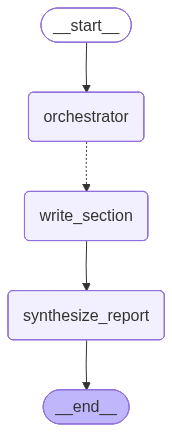

In [43]:
report_builder = StateGraph(ReportState)

report_builder.add_node('orchestrator', orchestrator_node)
report_builder.add_node('write_section', write_section_node)
report_builder.add_node('synthesize_report', synthesize_report_node)

report_builder.add_edge(START, "orchestrator")

report_builder.add_conditional_edges(
    "orchestrator",
    assign_workers,
    ["write_section"]
)

report_builder.add_edge("write_section", "synthesize_report")
report_builder.add_edge("synthesize_report", END)

report_graph = report_builder.compile()
report_graph

In [44]:
report_input = {
    'topic' : 'AI 기반 개인 맞춤형 학습 도우미',
    'completed_sections' : []
}

for chunk in report_graph.stream(
    report_input,
    stream_mode='updates',
    version='v2'
):
    update = chunk['data']

    for node_name, node_update in update.items():
        print(f"[실행 된 노드] : {node_name}")

        if "sections" in node_update:
            print("[섹션 목록]")
            for section in node_update['sections']:
                print("-", section)
        
        if "completed_sections" in node_update:
            print("[작성 완료한 섹션]")
            for section in node_update['completed_sections']:
                print("-", section)

        if "final_report" in node_update:
            print("[최종 보고서]\n", node_update['final_report'])

        print("=" * 100)

[실행 된 노드] : orchestrator
[섹션 목록]
- 서론
- AI 기반 학습 도우미의 개념
- 개인 맞춤형 학습의 중요성
- AI 기술의 역할과 적용 사례
- 개인 맞춤형 학습 도우미의 장점
- 도전 과제 및 개선 방향
- 미래 전망
- 결론
[작성 완료한 섹션]
[실행 된 노드] : write_section
[작성 완료한 섹션]
- ## 개인 맞춤형 학습의 중요성
개인 맞춤형 학습은 학습자의 개별 특성과 필요에 맞춘 교육 방법으로, 학습 효과를 극대화하는 데 중요한 역할을 한다. 전통적인 일괄적 교육 방식과 달리 맞춤형 학습은 학습자의 수준, 관심사, 학습 속도 등을 반영하여 최적의 학습 환경을 제공한다. 이러한 접근은 학습자의 동기 부여를 높이고 학습 성취도를 향상시키는 데 기여하며, AI 기술의 발전으로 개인 맞춤형 학습 도우미의 구현이 더욱 현실화되고 있다. 따라서 개인 맞춤형 학습은 현대 교육의 핵심 요소로 자리매김하고 있다.
[실행 된 노드] : write_section
[작성 완료한 섹션]
- ## 도전 과제 및 개선 방향
AI 기반 개인 맞춤형 학습 도우미의 주요 도전 과제는 데이터 프라이버시 보호와 정확한 학습자 이해에 있습니다. 학습자의 민감한 정보를 안전하게 관리하면서도 개별 학습 수준과 선호도를 정확하게 파악하는 기술적 어려움이 존재합니다. 또한, 다양한 학습 스타일과 환경에 적응하는 맞춤형 알고리즘 개발이 필요합니다. 향후 개선 방향으로는 강화된 개인정보 보호 기술 도입과 인공지능의 해석 가능성 향상, 그리고 지속적인 사용자 피드백 반영을 통한 학습 효과 극대화가 요구됩니다.
[실행 된 노드] : write_section
[작성 완료한 섹션]
- ## AI 기반 학습 도우미의 개념
AI 기반 학습 도우미는 인공지능 기술을 활용하여 학습자의 개별 특성과 필요에 맞춘 맞춤형 학습 지원을 제공하는 시스템을 의미한다. 이러한 도우미는 학습자의 수준, 학습 속도, 선호도 등을 분석하여 적합한 학습 콘텐츠와 피드백을 실시간으로 제공한다.